# Figure S9 - iMN purity at 96-well

Notes:

1. Only singlets
2. Reseed at 7 dpi with puro, then half media X with puro on 10 dpi (7 days with puro)
2. 14 dpi flow

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
no_yellow_viridis = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap('viridis', 256)(np.linspace(0,0.85,256)))

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_17349/4119890076.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  no_yellow_viridis = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap('viridis', 256)(np.linspace(0,0.85,256)))


# Look at post puro selection data

## Load data

In [2]:
# Base dir for data files
base_datadir = rd.datadir / "nat_attune" / "desNb-circuits" / "2025.03.10_desNb-reseed_14dpi"
# figure path
figpath = "./figures/2025.03.10_desNb-reseed_14dpi/"

cache_path = base_datadir / 'data.gzip'

if cache_path.exists():
    df_all = pd.read_parquet(cache_path)

else:

    # List of puro conc + directories
    # dirs = {'0ugmL': 0, '12ugmL':12, '24ugmL':24, '48ugmL':48, '96ugmL':96}
    dir_list = ['0nguL', '12-24-nguL', '48-96-nguL']

    # Store all data in list of dfs which will be converted to df at end
    df_all = list()
    # for (dir, puro) in dirs.items():
    for dir in dir_list:

        # Load as df and note header is on 0th row
        df = rd.flow.load_csv_with_metadata(
            base_datadir/dir/'export_singlets', base_datadir/f'well_metadata_{dir}.yaml')

        df_all.append(df)

    # Convert list of dfs into single df
    df_all = pd.concat(df_all, ignore_index=True)

    # Save shortened df
    df_all.to_parquet(rd.outfile(cache_path))

# Remove negative data
df = df_all.loc[( df_all["eGFP-A"] > 0) & (df_all["mRuby2-A"] > 0)]

# Convert puro to int
df = df.astype({'puro': 'int'})

# Get iMN count, yield and purity

## eGFP threshold and sitribution

In [3]:
df

,cond,rep,puro,well,population,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,...,eGFP-A,eGFP-H,eGFP-W,iRFP670-A,iRFP670-H,iRFP670-W,mRuby2-A,mRuby2-H,mRuby2-W,Time
0,desNb(EGFP),2,0,B7,Singlets,386752,203233,144,938,699,...,89.0,70.0,0,480.0,349,0,759.0,576.0,0,0.001013
1,desNb(EGFP),2,0,B7,Singlets,284560,211078,112,570,436,...,74.0,59.0,0,39.0,128,0,199.0,191.0,0,0.001013
2,desNb(EGFP),2,0,B7,Singlets,642345,280994,170,2002,918,...,25507.0,12513.0,110,1246.0,695,0,66552.0,34452.0,187,0.002026
5,desNb(EGFP),2,0,B7,Singlets,281114,204277,136,585,504,...,7724.0,5589.0,51,-13.0,112,0,19304.0,13561.0,70,0.012158
6,desNb(EGFP),2,0,B7,Singlets,284024,224745,111,370,363,...,44.0,43.0,0,-16.0,77,0,297.0,420.0,0,0.016210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2267527,desNb(EGFP),1,48,D6,Singlets,795222,247000,199,5154,1678,...,64224.0,30077.0,185,2661.0,936,0,1048580.0,487967.0,216,27.945200
2267528,desNb(EGFP),1,48,D6,Singlets,245187,176739,116,1025,735,...,9772.0,6798.0,56,801.0,619,0,491822.0,352485.0,135,27.957400
2267529,desNb(EGFP),1,48,D6,Singlets,256778,191732,123,1366,1004,...,22750.0,17186.0,68,1048.0,773,0,1047700.0,810172.0,133,27.973500
2267530,desNb(EGFP),1,48,D6,Singlets,641828,276422,173,4518,2570,...,25430.0,12124.0,89,5220.0,3185,48,1048580.0,557357.0,173,28.016000


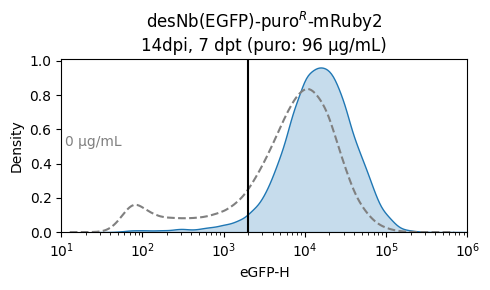

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Threshold for Hb9::GFP
eGFP_H_thresh = 2*10**3

# Plot eGFP-H
x = 'eGFP-H'

sns.kdeplot(data=df.loc[(df['cond'] == 'desNb(EGFP)') & (df['puro'] == 96) & (df['rep'] == 3)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=True)


# Plot 0 ug/mL ctrl
sns.kdeplot(data=df.loc[(df['cond'] == 'desNb(EGFP)') & (df['puro'] == 0) & (df['rep'] == 3)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('0 µg/mL', (0.08, 0.5), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title('desNb(EGFP)-puro$^{R}$-mRuby2\n14dpi, 7 dpt (puro: 96 µg/mL)')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-eGFP.svg', bbox_inches='tight')

In [25]:
# Categorize iMNs based on eGFP_thresh
df['eGFP_cat'] = np.where(df['eGFP-H'] > eGFP_H_thresh, 'iMN', 'fib') 

# Get total counts and percent of GFP-H+
group = ['cond', 'puro', 'rep']
count_df_reps = df.groupby([*group, 'well', 'eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')

# Get iMN yield per condition
seedNum = 1.25e3 # Seeded 10k MEFs/96-well
data_iMN_yield_reps = (count_df_reps*100/seedNum).reset_index(name='yield')
data_iMN_count_reps = count_df_reps.reset_index(name='count')


# Extract just the iMNs
data_iMN_yield_reps = data_iMN_yield_reps.loc[(data_iMN_yield_reps['eGFP_cat'] == 'iMN')]
data_iMN_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'iMN')]
data_iMN_count_reps = data_iMN_count_reps.loc[(data_iMN_count_reps['eGFP_cat'] == 'iMN')]
    
# Collapse to bio reps
data_iMN_yield = data_iMN_yield_reps.groupby([*group]).mean().reset_index()
data_iMN_percent = data_iMN_percent_reps.groupby([*group]).mean().reset_index()
data_iMN_count = data_iMN_count_reps.groupby([*group]).mean().reset_index()

/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_17349/3199949967.py:22: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data_iMN_yield = data_iMN_yield_reps.groupby([*group]).mean().reset_index()
/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_17349/3199949967.py:23: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data_iMN_percent = data_iMN_percent_reps.groupby([*group]).mean().reset_index()
/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_17349/3199949967.py:24: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric

## Look at eGFP distribution changes

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


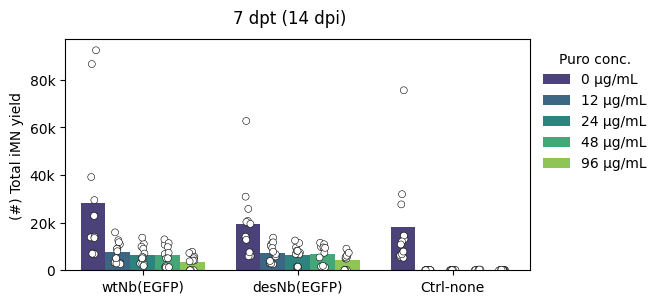

In [ ]:
palette = 'viridis'
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]
# General plotting params
x = 'cond'
y = 'count'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]

hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_count_reps,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_count_reps,
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(#) Total iMN yield')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


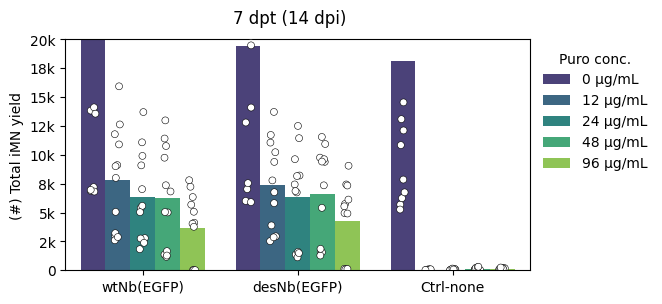

In [ ]:
palette = 'viridis'
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]
# General plotting params
x = 'cond'
y = 'count'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]

hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_count_reps,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_count_reps,
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.set_ylim([0, 20e3])
ax.yaxis.set_label_text('(#) Total iMN yield')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count_zoom.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


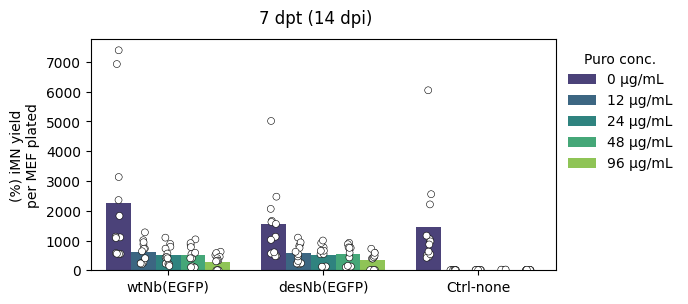

In [ ]:
# General plotting params
x = 'cond'
y = 'yield'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

palette = 'viridis'

# Plot iMN yield
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_yield_reps,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_yield_reps,
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.xaxis.set_label_text('')
# ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-yield.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


Text(0.5, 0.98, '7 dpt (14 dpi)')

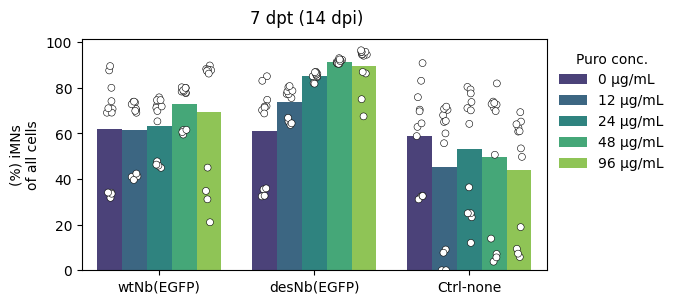

In [ ]:
# General plotting params
x = 'cond'
y = 'percent'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

palette = 'viridis'
# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_percent_reps,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_percent_reps,
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-purity.svg', bbox_inches='tight')

## Do it without rep 1

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


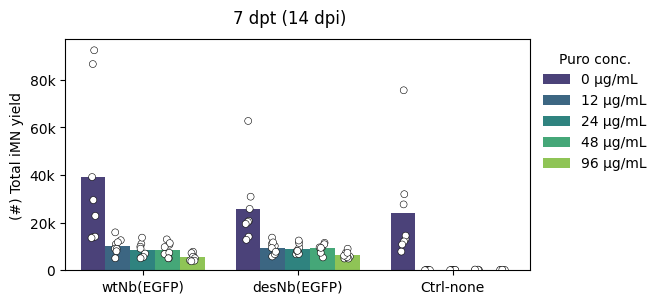

In [31]:
palette = 'viridis'
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]
# General plotting params
x = 'cond'
y = 'count'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]

hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_count_reps[data_iMN_count_reps.rep != 1],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_count_reps[data_iMN_count_reps.rep != 1],
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(#) Total iMN yield')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
plt.savefig(figpath + 'bar_iMN-count_noRep1.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


Text(0.5, 0.98, '7 dpt (14 dpi)')

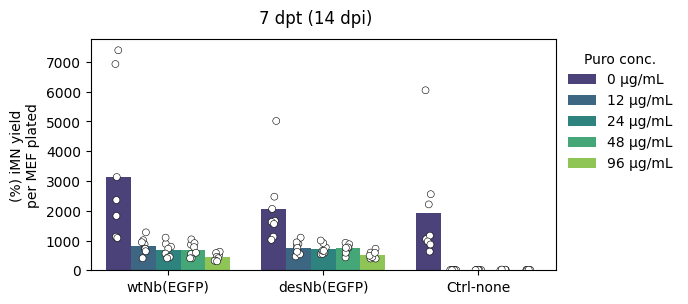

In [ ]:
# General plotting params
x = 'cond'
y = 'yield'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

palette = 'viridis'

# Plot iMN yield
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_yield_reps[data_iMN_yield_reps.rep != 1],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_yield_reps[data_iMN_yield_reps.rep != 1],
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.xaxis.set_label_text('')
# ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-yield_noRep1.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


Text(0.5, 0.98, '7 dpt (14 dpi)')

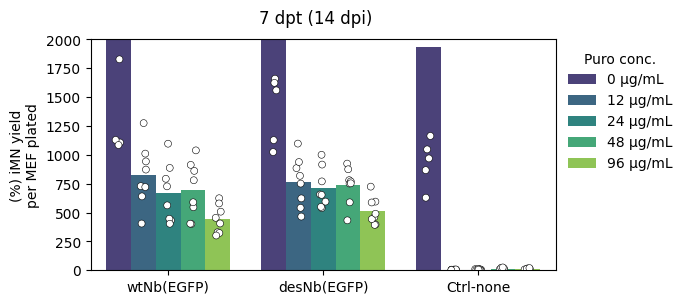

In [ ]:
# General plotting params
x = 'cond'
y = 'yield'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

palette = 'viridis'

# Plot iMN yield
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_yield_reps[data_iMN_yield_reps.rep != 1],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_yield_reps[data_iMN_yield_reps.rep != 1],
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.xaxis.set_label_text('')
ax.set_ylim([0, 2000])
# ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-yield_noRep1_zoom.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


Text(0.5, 0.98, '7 dpt (14 dpi)')

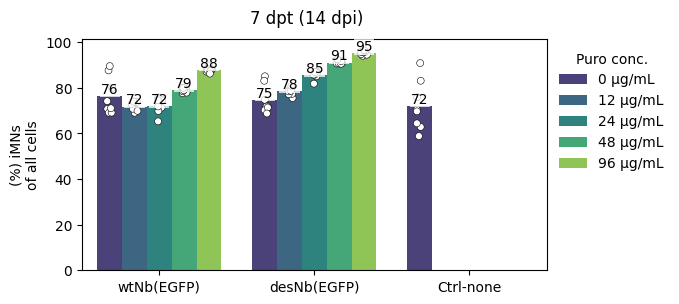

In [ ]:
# General plotting params
x = 'cond'
y = 'percent'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

palette = 'viridis'
# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_percent_reps[data_iMN_percent_reps.rep != 1],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_percent_reps[data_iMN_percent_reps.rep != 1],
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=0)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-purity_noRep1.svg', bbox_inches='tight')

Ignore purity for wells with very few cells as it's unreliable

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


Text(0.5, 0.98, '7 dpt (14 dpi)')

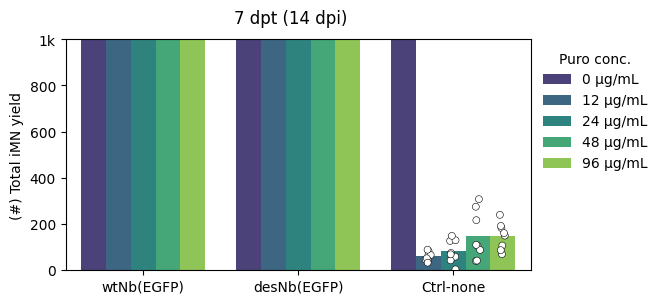

In [ ]:
palette = 'viridis'
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]
# General plotting params
x = 'cond'
y = 'count'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]

hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_count_reps[data_iMN_count_reps.rep != 1],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_count_reps[data_iMN_count_reps.rep != 1],
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

ax.set_ylim([0, 1e3])
# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(#) Total iMN yield')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing

In [26]:
# If there are less than 500 cells per row, ignore it in purity
for index, row in data_iMN_count_reps.iterrows():
    if row['count'] < 500:
        data_iMN_percent_reps.loc[index, 'percent'] = 0

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


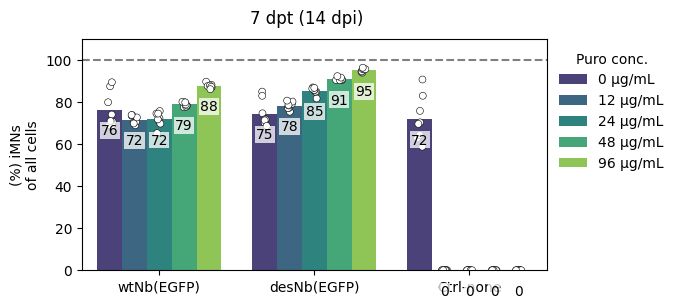

In [32]:
# General plotting params
x = 'cond'
y = 'percent'
order = ["wtNb(EGFP)", "desNb(EGFP)",  "Ctrl-none"]
hue = 'puro'
hue_order = [0, 12, 24, 48, 96]

palette = 'viridis'
# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=data_iMN_percent_reps[data_iMN_percent_reps.rep != 1],
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)
sns.stripplot(
    ax=ax, data=data_iMN_percent_reps[data_iMN_percent_reps.rep != 1],
    x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker='o',
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '12': '12 µg/mL',  '24': '24 µg/mL',  '48': '48 µg/mL',  '96': '96 µg/mL',}
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=[lmap[label] for (i, label) in enumerate(l)],
    title='Puro conc.', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_ylim(0, 110)

# Format
plt.suptitle('7 dpt (14 dpi)')
# fig.tight_layout()  # Helps improve white spacing
plt.savefig(figpath + 'bar_iMN-purity_noRep1_final.svg', bbox_inches='tight')